# Product User Churn Prediction & Analytics

## Exploratory Data Analysis

This notebook explores user engagement and churn behavior for a fictional subscription-based productivity application.

### Objectives

- Understand the structure of the churn dataset
- Examine the distribution of churn
- Compare engagement between churned and non-churned users
- Analyze activity recency
- Explore behavioral metrics associated with churn
- Identify product signals that can inform churn prediction

The analysis uses user behavior from the feature window (January-April 2026) and churn outcomes from the outcome window (May-June 2026).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/ml_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3307, 19)


,user_id,total_events,total_sessions,active_days,login_count,product_view_count,search_count,add_to_cart_count,purchase_count,subscription_count,days_since_last_activity,days_since_last_login,days_since_last_product_view,events_per_active_day,sessions_per_active_day,search_rate,cart_rate,purchase_rate,churn
0,U00001,14,6,5,5,5,2,1,0,0,87,87,87,2.80,1.20,0.1429,0.0714,0.0000,0
1,U00002,4,2,1,1,1,1,0,0,0,9,9,9,4.00,2.00,0.2500,0.0000,0.0000,0
2,U00003,119,39,38,38,38,24,16,1,1,0,0,0,3.13,1.03,0.2017,0.1345,0.0084,0
3,U00004,15,6,5,5,5,2,2,0,0,43,43,43,3.00,1.20,0.1333,0.1333,0.0000,0
4,U00005,3,2,1,1,1,0,0,0,0,73,73,73,3.00,2.00,0.0000,0.0000,0.0000,0


In [2]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['user_id', 'total_events', 'total_sessions', 'active_days', 'login_count', 'product_view_count', 'search_count', 'add_to_cart_count', 'purchase_count', 'subscription_count', 'days_since_last_activity', 'days_since_last_login', 'days_since_last_product_view', 'events_per_active_day', 'sessions_per_active_day', 'search_rate', 'cart_rate', 'purchase_rate', 'churn']

Data types:


user_id                             str
total_events                      int64
total_sessions                    int64
active_days                       int64
login_count                       int64
product_view_count                int64
search_count                      int64
add_to_cart_count                 int64
purchase_count                    int64
subscription_count                int64
days_since_last_activity          int64
days_since_last_login             int64
days_since_last_product_view      int64
events_per_active_day           float64
sessions_per_active_day         float64
search_rate                     float64
cart_rate                       float64
purchase_rate                   float64
churn                             int64
dtype: object


Missing values:


user_id                         0
total_events                    0
total_sessions                  0
active_days                     0
login_count                     0
product_view_count              0
search_count                    0
add_to_cart_count               0
purchase_count                  0
subscription_count              0
days_since_last_activity        0
days_since_last_login           0
days_since_last_product_view    0
events_per_active_day           0
sessions_per_active_day         0
search_rate                     0
cart_rate                       0
purchase_rate                   0
churn                           0
dtype: int64


Duplicate rows: 0


In [3]:
churn_counts = df["churn"].value_counts().sort_index()

churn_summary = pd.DataFrame({
    "Users": churn_counts,
    "Percentage": (churn_counts / len(df) * 100).round(2)
})

churn_summary.index = ["Non-Churned", "Churned"]

display(churn_summary)

print(f"\nOverall churn rate: {df['churn'].mean() * 100:.2f}%")

,Users,Percentage
Non-Churned,3217,97.28
Churned,90,2.72



Overall churn rate: 2.72%


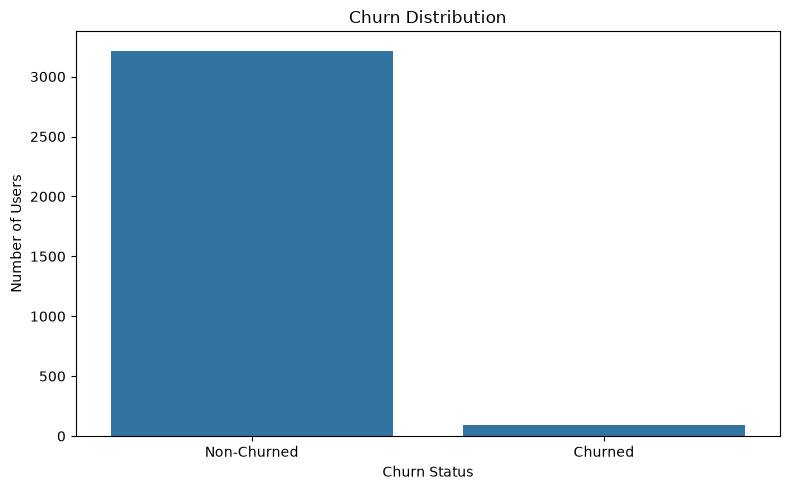

In [4]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Users")
plt.xticks([0, 1], ["Non-Churned", "Churned"])

plt.tight_layout()
plt.show()

In [5]:
engagement_features = [
    "total_events",
    "total_sessions",
    "active_days",
    "login_count",
    "product_view_count",
    "search_count",
    "add_to_cart_count",
    "purchase_count",
    "subscription_count"
]

engagement_by_churn = (
    df.groupby("churn")[engagement_features]
      .mean()
      .T
)

engagement_by_churn.columns = ["Non-Churned", "Churned"]

display(engagement_by_churn.round(2))

,Non-Churned,Churned
total_events,43.71,55.97
total_sessions,15.14,18.96
active_days,14.17,17.96
login_count,14.14,17.96
product_view_count,14.14,17.96
search_count,8.50,10.79
add_to_cart_count,4.95,6.27
purchase_count,0.65,1.00
subscription_count,0.30,1.00


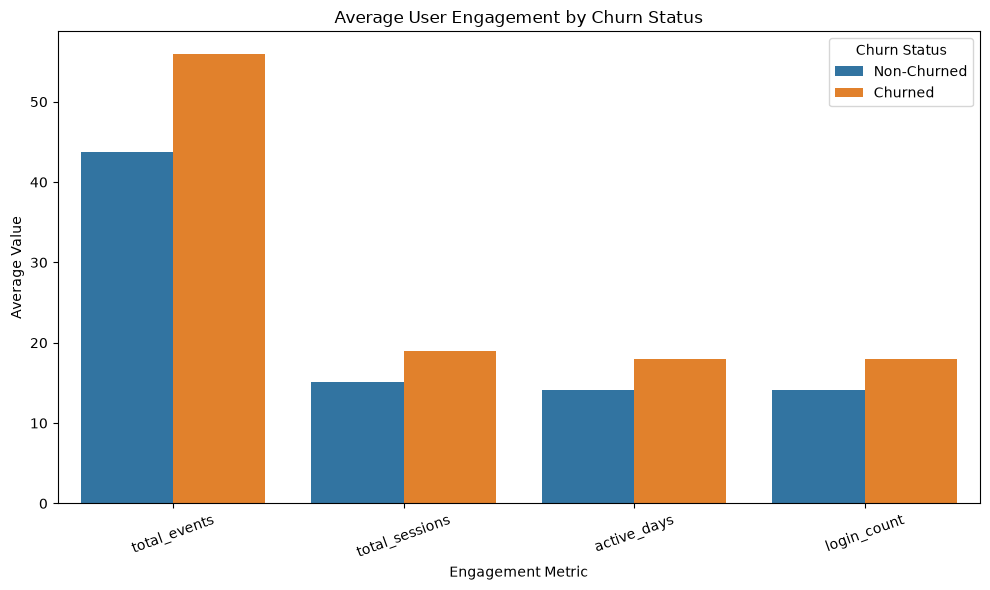

In [6]:
engagement_plot = (
    df.groupby("churn")[[
        "total_events",
        "total_sessions",
        "active_days",
        "login_count"
    ]]
    .mean()
    .reset_index()
)

engagement_plot["churn"] = engagement_plot["churn"].map({
    0: "Non-Churned",
    1: "Churned"
})

engagement_long = engagement_plot.melt(
    id_vars="churn",
    var_name="Metric",
    value_name="Average"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=engagement_long,
    x="Metric",
    y="Average",
    hue="churn"
)

plt.title("Average User Engagement by Churn Status")
plt.xlabel("Engagement Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=20)
plt.legend(title="Churn Status")

plt.tight_layout()
plt.show()

In [7]:
recency_features = [
    "days_since_last_activity",
    "days_since_last_login",
    "days_since_last_product_view"
]

recency_by_churn = (
    df.groupby("churn")[recency_features]
      .mean()
      .T
)

recency_by_churn.columns = ["Non-Churned", "Churned"]

display(recency_by_churn.round(2))

,Non-Churned,Churned
days_since_last_activity,46.38,20.64
days_since_last_login,47.57,20.64
days_since_last_product_view,47.57,20.64


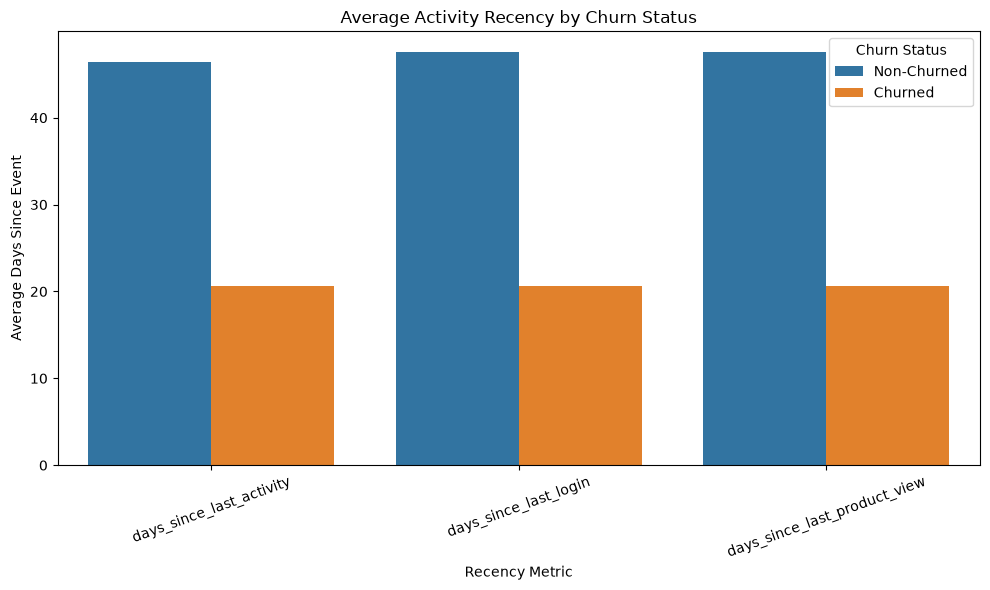

In [8]:
recency_plot = (
    df.groupby("churn")[[
        "days_since_last_activity",
        "days_since_last_login",
        "days_since_last_product_view"
    ]]
    .mean()
    .reset_index()
)

recency_plot["churn"] = recency_plot["churn"].map({
    0: "Non-Churned",
    1: "Churned"
})

recency_long = recency_plot.melt(
    id_vars="churn",
    var_name="Recency Metric",
    value_name="Average Days"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=recency_long,
    x="Recency Metric",
    y="Average Days",
    hue="churn"
)

plt.title("Average Activity Recency by Churn Status")
plt.xlabel("Recency Metric")
plt.ylabel("Average Days Since Event")
plt.xticks(rotation=20)
plt.legend(title="Churn Status")

plt.tight_layout()
plt.show()

In [9]:
behavior_features = [
    "events_per_active_day",
    "sessions_per_active_day",
    "search_rate",
    "cart_rate",
    "purchase_rate"
]

behavior_by_churn = (
    df.groupby("churn")[behavior_features]
      .mean()
      .T
)

behavior_by_churn.columns = ["Non-Churned", "Churned"]

display(behavior_by_churn.round(3))

,Non-Churned,Churned
events_per_active_day,3.202,3.193
sessions_per_active_day,1.176,1.084
search_rate,0.185,0.186
cart_rate,0.107,0.108
purchase_rate,0.017,0.025


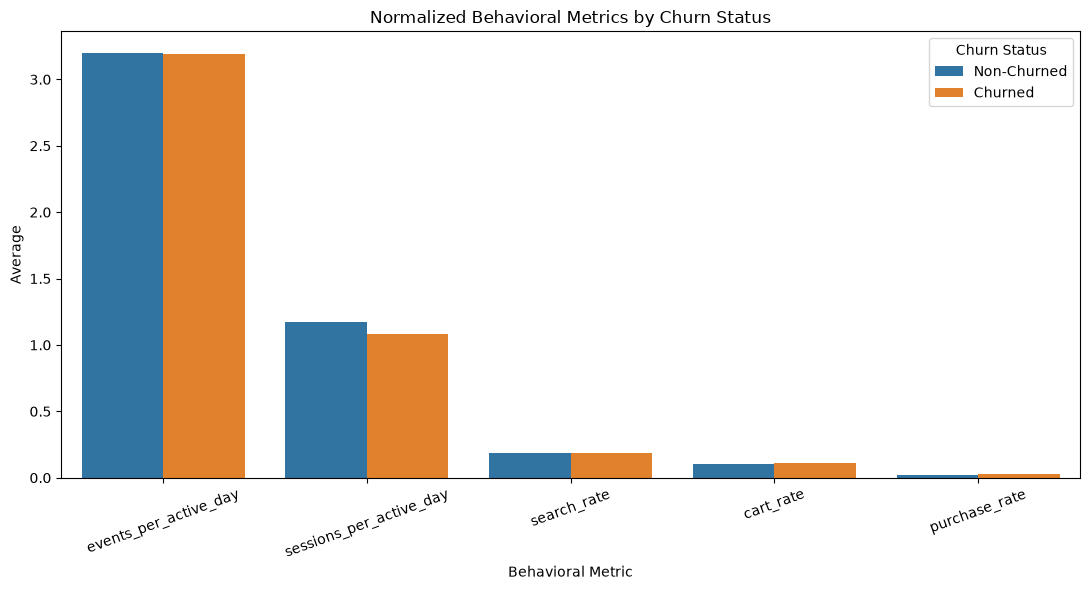

In [10]:
behavior_plot = (
    df.groupby("churn")[[
        "events_per_active_day",
        "sessions_per_active_day",
        "search_rate",
        "cart_rate",
        "purchase_rate"
    ]]
    .mean()
    .reset_index()
)

behavior_plot["churn"] = behavior_plot["churn"].map({
    0: "Non-Churned",
    1: "Churned"
})

behavior_long = behavior_plot.melt(
    id_vars="churn",
    var_name="Behavioral Metric",
    value_name="Average"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=behavior_long,
    x="Behavioral Metric",
    y="Average",
    hue="churn"
)

plt.title("Normalized Behavioral Metrics by Churn Status")
plt.xlabel("Behavioral Metric")
plt.ylabel("Average")
plt.xticks(rotation=20)
plt.legend(title="Churn Status")

plt.tight_layout()
plt.show()

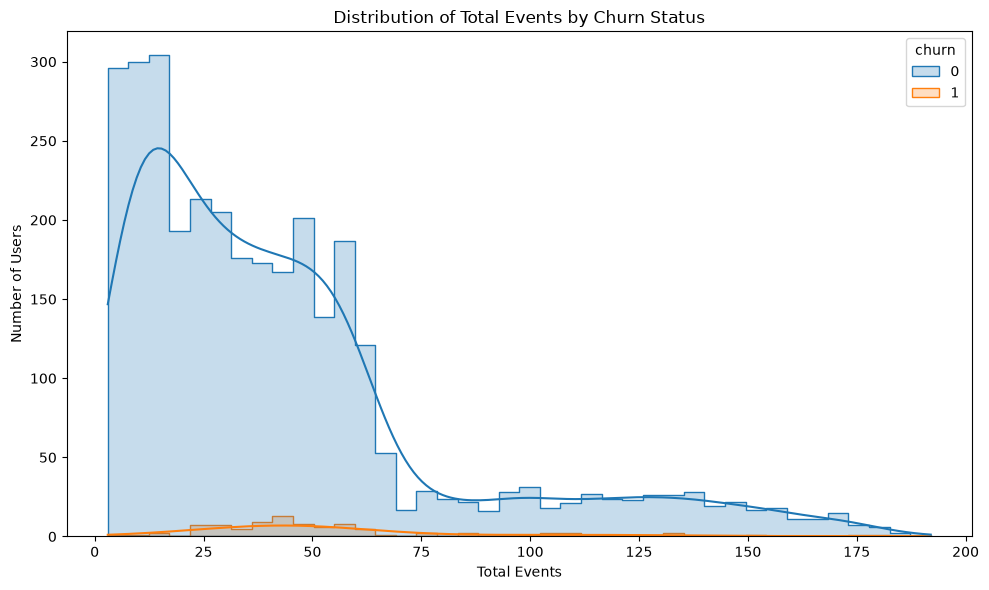

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="total_events",
    hue="churn",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Distribution of Total Events by Churn Status")
plt.xlabel("Total Events")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

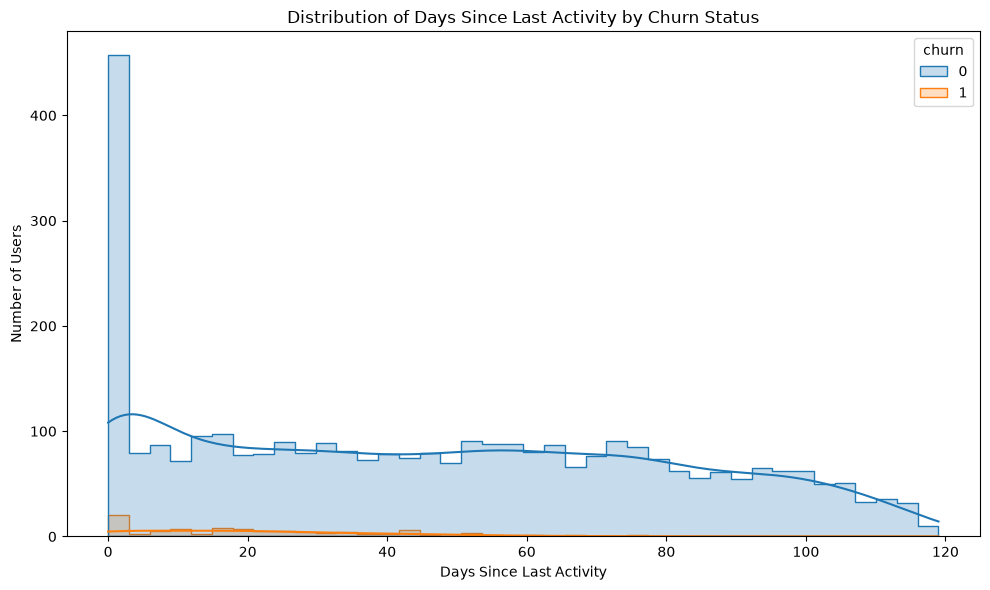

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="days_since_last_activity",
    hue="churn",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Distribution of Days Since Last Activity by Churn Status")
plt.xlabel("Days Since Last Activity")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

In [13]:
correlations = (
    df.drop(columns="user_id")
      .corr()["churn"]
      .drop("churn")
      .sort_values(key=abs, ascending=False)
)

display(correlations.to_frame("Correlation with Churn").round(3))

,Correlation with Churn
subscription_count,0.243
days_since_last_product_view,-0.126
days_since_last_login,-0.126
days_since_last_activity,-0.122
purchase_count,0.119
sessions_per_active_day,-0.069
purchase_rate,0.060
total_events,0.053
product_view_count,0.049
login_count,0.049


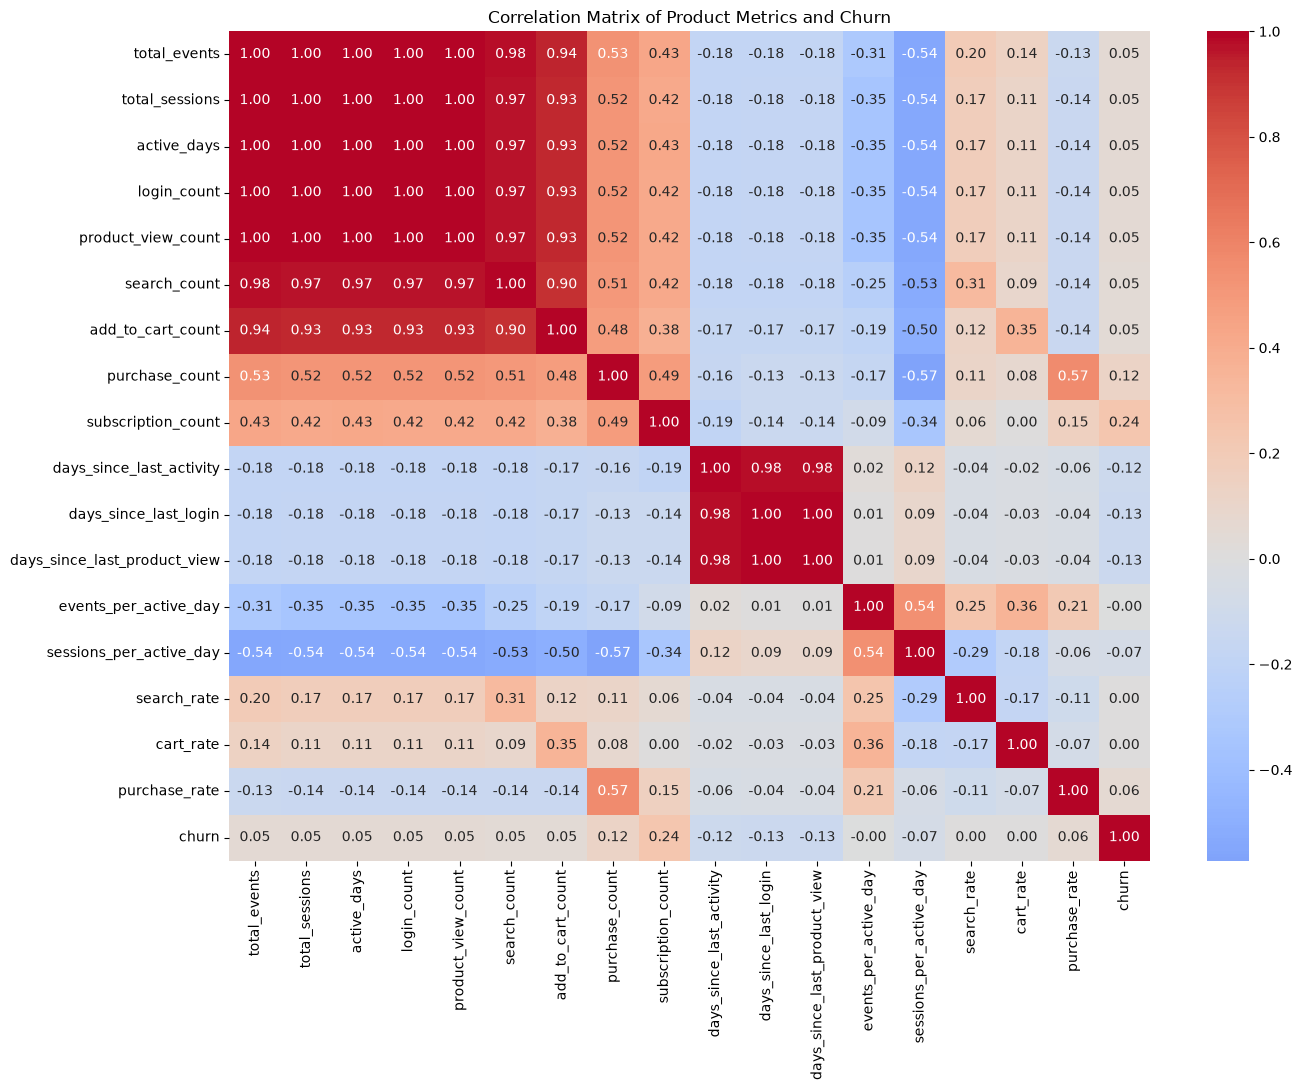

In [14]:
correlation_features = [
    "total_events",
    "total_sessions",
    "active_days",
    "login_count",
    "product_view_count",
    "search_count",
    "add_to_cart_count",
    "purchase_count",
    "subscription_count",
    "days_since_last_activity",
    "days_since_last_login",
    "days_since_last_product_view",
    "events_per_active_day",
    "sessions_per_active_day",
    "search_rate",
    "cart_rate",
    "purchase_rate",
    "churn"
]

corr_matrix = df[correlation_features].corr()

plt.figure(figsize=(14, 11))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Product Metrics and Churn")
plt.tight_layout()
plt.show()

## EDA Summary

The exploratory analysis highlights several patterns in the synthetic product dataset:

- The dataset contains **3,307 eligible users**, with **90 churned users (2.72%)**, creating a highly imbalanced churn target.
- Churned users show higher average raw engagement counts across several product metrics, including events, sessions and active days.
- Normalized behavioral rates are much closer between churned and non-churned users, suggesting that raw activity volume and activity intensity capture different aspects of user behavior.
- Churned users have fewer average days since their last activity, login and product view in this synthetic dataset.
- Subscription history and purchase activity show the strongest positive pairwise associations with churn.
- Several raw engagement features are highly correlated with one another, reflecting the structure of the synthetic event-generation process.
- Correlation analysis identifies linear associations but does not capture nonlinear relationships or imply causality.

These observations provide the foundation for the feature engineering and machine-learning stages of the project.